# End-to-end Semantic Deduplication on Text Data

GPU accelerated implementation of [SemDeDup: Data-efficient learning at web-scale through semantic deduplication](https://arxiv.org/abs/2303.09540). For more information about semantic deduplication in NeMo Curator, refer to the [Semantic Deduplication](https://docs.nvidia.com/nemo/curator/latest/curate-text/process-data/deduplication/semdedup.html) documentation page.

The tutorial here shows how to run Semantic Duplication on text data by executing a single workflow which does the following:

1. Read original dataset
2. Run embedding generation
3. Use K-Means to cluster the embeddings
4. Compute pairwise similarity inside each of the clusters
5. Identify duplicates based on `eps` provided (and `ranking_strategy`)
6. Remove duplicates from the original dataset

We also allow users to also run these steps independently, which can be seen in the step by step tutorial in the same directory as this tutorial.

In [1]:
import os

# Silence Curator logs via Loguru
os.environ["LOGURU_LEVEL"] = "ERROR"

import pandas as pd
import pyarrow.parquet as pq

input_path = os.path.abspath("./input")
semantic_out_dir = os.path.abspath("./output/e2e")
output_path = os.path.join(semantic_out_dir, "output")
cache_path = os.path.join(semantic_out_dir, "cache")
input_filetype = (
    "parquet"  # this can be either of jsonl or parquet (you'll need to change how input data is generated)
)
output_filetype = "parquet"  # this can be either of jsonl or parquet

## Generate Input Data

We generate input data if we don't have files in the path above
 - We load the [TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) dataset (just the train partition) which has 2,119,719 rows
 - We split into shards such that no shard has more than 10,000 rows
 - We create a new ID column which is UUID
 - We write out ~212 files

In [2]:
from nemo_curator.utils.file_utils import get_all_file_paths_under

if len(get_all_file_paths_under(input_path)) == 0:
    import os
    import uuid

    import numpy as np
    from datasets import load_dataset

    input_df = load_dataset("roneneldan/TinyStories", split="train").to_pandas()
    num_rows_per_file = 10_000

    os.makedirs(input_path, exist_ok=True)

    for i, start_idx in enumerate(range(0, len(input_df), num_rows_per_file)):
        end_idx = min(len(input_df), start_idx + num_rows_per_file)
        subset_df = input_df.iloc[start_idx:end_idx].copy()
        subset_df["id"] = [str(uuid.uuid4()) for _ in range(len(subset_df))]
        subset_df.to_parquet(os.path.join(input_path, f"part_{i}.parquet"), index=False)

    print(f"Created {len(os.listdir(input_path))} files")

## Running as a Single Stage (End-to-End)

See the [API Reference](https://docs.nvidia.com/nemo/curator/latest/apidocs/stages/stages.text.deduplication.semantic.html#stages.text.deduplication.semantic.TextSemanticDeduplicationWorkflow) for more information about the `TextSemanticDeduplicationWorkflow` class.

### Performance Notes
Set `id_generator=True` if you want to remove duplicates from large datasets (i.e. when `perform_removal=True`).

- The ID Generator gives each row a unique increasing integer ID, based on the order files are read.
- When we find duplicates, we save these integer IDs in sorted files with multiple row groups.
- During removal, reading the same files will give the same integer IDs, using the min/max ID values, we can find all corresponding duplicates.
- This makes finding and removing duplicates much faster.

In [ ]:
from nemo_curator.stages.deduplication.semantic import RankingStrategy
from nemo_curator.stages.text.deduplication.semantic import TextSemanticDeduplicationWorkflow

workflow = TextSemanticDeduplicationWorkflow(
    input_path=input_path,
    output_path=output_path,
    cache_path=cache_path,
    perform_removal=True,
    # Embedding generation parameters
    text_field="text",
    model_identifier="google/embeddinggemma-300m",
    embedding_max_chars=None,
    embedding_pretokenize=False,
    embedding_vllm_init_kwargs={"gpu_memory_utilization": 0.9},  # lower if OOM occurs
    # Semantic deduplication parameters
    n_clusters=100,  # this number can be much higher when the data is large
    # For large scale data removal we should use CURATOR_DEDUP_ID_STR
    id_field="id",
    eps=0.01,
    # K-Means clustering parameters
    ranking_strategy=RankingStrategy(metadata_cols=["cosine_dist_to_cent"], ascending=True),
    pairwise_batch_size=1024,
    # ID generator parameters
    # For large scale data removal we should set use_id_generator to True
    use_id_generator=False,
    id_generator_state_file=None,
    # I/O parameters
    input_filetype=input_filetype,
    input_files_per_partition=1,
    output_filetype=output_filetype,
    verbose=True,
    clear_output=True,
)

In [ ]:
import torch

from nemo_curator.core.client import RayClient

# Number of GPUs should be roughly 2x the memory of the embeddings
NUM_GPUS = 4

if torch.cuda.device_count() < NUM_GPUS:
    error_msg = "The number of GPUs on this machine are lesser than the default this tutorial was tested with, please update `num_gpus` passed into `RayClient`"
    raise ValueError(error_msg)

client = RayClient(num_cpus=64, num_gpus=NUM_GPUS)
client.start()
try:
    workflow.run()
finally:
    client.stop()

### Looking at Intermediate Results and Output

#### 1. Embeddings Results

1. `id` : The ID field from our original dataset. 
    - For all subsequent steps this is assumed to be the  `id_field`.
    - If you had set `use_id_generator` to `True` then instead of this you would see the `_curator_dedup_id` specified. 
        - The ID in that field is generated using our `IdGenerator` which assigns integer IDs to each row in the input data that later is used for removal. 
2. `embeddings` : The embedding generated by the model we used above.

In [5]:
embeddings_path = os.path.join(cache_path, "embeddings")

pd.read_parquet(os.path.join(embeddings_path, os.listdir(embeddings_path)[0])).head()

,id,embeddings
0,e027155d-c4d7-4662-8dc2-6564cc0a3d32,"[-0.09730339795351028, 0.02866889350116253, 0...."
1,51b8186c-bf48-4db8-83c7-a72b23e02025,"[-0.09646597504615784, 0.005821706261485815, 0..."
2,69caf089-e77a-436b-b9d0-a20807a313c9,"[-0.09041747450828552, 0.034036893397569656, 0..."
3,00095084-076b-4eee-beb6-b97749445889,"[-0.09932446479797363, -0.016051072627305984, ..."
4,650e46c1-60d5-442c-a479-e10599d6a691,"[-0.07266555726528168, 0.06062197685241699, 0...."


#### 2. K-Means Results

1. `id` : The IDs of the rows that belong to the cluster.
2. `embeddings` : These are later used for pairwise similarity.
3. `l2_dist_to_cent` / `cosine_dist_to_cent` : This represents how far (l2 distance or cosine distance) a sample is from our cluster's centroid.
    - These fields help us define how we want to prioritize ranking within our cluster. See `RankingStrategy`
    - If we had other `metadata_fields` provided they would be used here instead.


In [6]:
kmeans_path_first_centroid = os.path.join(cache_path, "semantic_dedup", "kmeans_results", "centroid=0")

pd.read_parquet(os.path.join(kmeans_path_first_centroid, os.listdir(kmeans_path_first_centroid)[0])).head()

,id,embeddings,l2_dist_to_cent,cosine_dist_to_cent
0,8ea839cf-9486-4fbf-82bf-179e2686ff51,"[-0.0604501, 0.022936057, 0.041397367, 0.03238...",0.703949,0.289604
1,16623653-d508-40bb-b75c-f19108e48375,"[-0.06968275, 0.036030754, 0.045684896, -0.032...",0.764228,0.350659
2,7dba0aea-db11-443b-a44b-4da8434f69a4,"[-0.051915932, 0.00086185976, 0.08417062, 0.00...",0.650030,0.239239
3,e04c5c73-a25b-4f80-a1fc-b0cf5196257f,"[-0.06667237, -0.00064728904, 0.0346154, 0.014...",0.542937,0.151099
4,62aad0bf-0854-458a-ada4-e91017cc2e74,"[-0.086764686, 0.011363951, 0.07833106, 0.0079...",0.767696,0.354325


#### 3. Pairwise Similarity Result

1. `id` : The identifier for the duplicate row.
2. `max_id` : The closest pair for the duplicate row.
3. `cosine_sim_score` : The cosine similarity between the two points.


In [7]:
pairwise_path = os.path.join(cache_path, "semantic_dedup", "pairwise_results")

pd.read_parquet(os.path.join(pairwise_path, "cluster_0.parquet")).head()

,id,max_id,cosine_sim_score
0,5763db1b-e420-4448-b418-afc530f6acfe,5763db1b-e420-4448-b418-afc530f6acfe,0.000000
1,554c039e-7c62-4348-b84c-49b44cd2e0df,5763db1b-e420-4448-b418-afc530f6acfe,0.999999
2,45b7c2e6-34c1-4ec3-a4ba-416433b5084e,5763db1b-e420-4448-b418-afc530f6acfe,0.820020
3,d7cae3d1-b369-4150-b7bb-dd0c643e8d7f,5763db1b-e420-4448-b418-afc530f6acfe,0.829051
4,c058abba-c6c0-4d2a-9a1d-bc83fbfc5838,5763db1b-e420-4448-b418-afc530f6acfe,0.789721


#### Looking at Similar Results

We can look at two rows and see why the embedding model thinks they're similar.
We can use this to guide our decision about the `eps` parameter.

We use two `554c039e-7c62-4348-b84c-49b44cd2e0df` and	`5763db1b-e420-4448-b418-afc530f6acfe` which have cosine similarity of	`0.99`.

And we notice that the theme of the data is very similar. 

**NOTE: If you run with `use_id_generator=True` (which is important to perform removal at large scale) you will see the IDs which were generated internally, and there won't be a way to perform this step, as there is no simple way of getting the old mappings of IDs to the new mappings of IDs.**

In [10]:
from pprint import pprint

pprint(
    pd.read_parquet(
        input_path,
        filters=[("id", "in", {"554c039e-7c62-4348-b84c-49b44cd2e0df", "5763db1b-e420-4448-b418-afc530f6acfe"})],
    ).to_dict(orient="records")
)

[{'id': '5763db1b-e420-4448-b418-afc530f6acfe',
  'text': 'Once upon a time there was a nice girl. She wanted to find '
          'something yummy to eat, so she took a walk in the sunny park. She '
          'saw many apples on the trees and wanted to pick one. She reached '
          'out and grabbed the biggest apple she saw and picked it from the '
          'tree. \n'
          '\n'
          'When the girl ate the apple, it tasted so delicious! She was so '
          'happy and decided to pick more apples to take home. She filled her '
          "basket with lots of yummy apples and couldn't wait to share them "
          'with her family. \n'
          '\n'
          'The girl was so proud of how many delicious apples she had picked. '
          'She put the basket on her head and carried it home. When she got '
          'home, her family was very happy to eat the yummy, delicious apples! '
          'They all had a wonderful time together, eating and laughing. \n'
          '\

##### Visualizing Similarity in the Dataset


Depending on our dataset size we can read through all of the files and plot how much data is similar to one another.
Here we show how to read file by file and then perform a reduce. 

In our dataset we can see that ~20% of our data has cosine similarity of 0.9 or more.

Based on the analysis here and above (where we see similar text fields) we can decide what our `eps` should be. 

Note that in this tutorial we pre-ran with `eps` set and `perform_removal` as `True`.

Ideally, users do this analysis, inspect the duplicates, come up with an `eps`, run a pipeline that includes the `IdentifyDuplicates` stage, and finally perform removal.

In [11]:
from collections import Counter
from functools import reduce

import numpy as np


def get_bins(df: pd.DataFrame, num_bins: int = 1_000) -> dict[float, int]:
    bins = np.linspace(0, 1.01, num_bins)

    return Counter(
        pd.cut(df["cosine_sim_score"], bins=bins, labels=bins[1:], retbins=False, include_lowest=True, right=True)
        .value_counts()
        .to_dict()
    )


similarity_across_dataset = reduce(
    lambda x, y: x + y,
    [
        get_bins(pd.read_parquet(os.path.join(pairwise_path, f), columns=["cosine_sim_score"]), num_bins=1000)
        for f in os.listdir(pairwise_path)
    ],
)

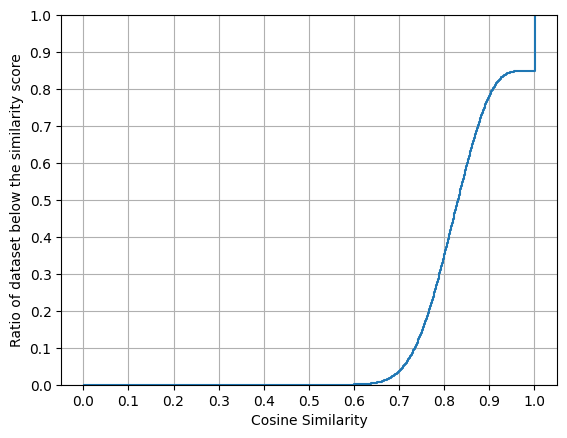

In [12]:
import matplotlib.pyplot as plt

plt.ecdf(x=similarity_across_dataset.keys(), weights=similarity_across_dataset.values())
plt.xticks(np.linspace(0, 1, 11))
plt.yticks(np.linspace(0, 1, 11))
plt.xlabel("Cosine Similarity")
plt.ylabel("Ratio of dataset below the similarity score")
plt.grid()
plt.show()

#### Looking at Duplicates

- `id` : This is a list of all IDs that are above our similarity threshold `eps`.

In [13]:
duplicates_path = os.path.join(output_path, "duplicates")

pd.read_parquet(os.path.join(duplicates_path, os.listdir(duplicates_path)[0])).head()

,id
0,00037c32-41e2-41b6-a772-027cf7b6951b
1,0003ee4e-81a6-42f3-89a9-10ba101bcf9b
2,00058fc8-a4e6-46a1-b149-0f53dab9bbe1
3,000f25c2-bf7a-41b8-9400-32773acb1672
4,0011bf4e-0043-46e6-873a-693050ad4fd2


In [14]:
num_duplicates = sum(pq.read_metadata(os.path.join(duplicates_path, f)).num_rows for f in os.listdir(duplicates_path))
print(f"We found {num_duplicates:,} duplicates in the dataset")

We found 320,470 duplicates in the dataset


#### Looking at the Deduplicated Dataset

Here we see all the original columns. 

We can control the schema of this by specifying the `output_fields` argument in the workflow definition.

If you had set `use_id_generator=True` with the default output schema, the deduplicated output now drops the generated `_curator_dedup_id` before writing. If you want it preserved, include it explicitly in `output_fields`.

In [15]:
deduplicated_path = os.path.join(output_path, "deduplicated")

pd.read_parquet(os.path.join(deduplicated_path, os.listdir(deduplicated_path)[0])).head()

,text,id
0,"Once upon a time, there was a big dog named Ma...",5c419775-ac60-416c-a95a-f570701d47d0
1,"Once upon a time, there was a shy little girl ...",3320599d-7832-40f3-bf26-2e5dd81a449f
2,"Once upon a time, there was a little boy named...",2a770084-48eb-4444-bb49-0a2239a6ca09
3,"Once upon a time, there was a little girl name...",02f01879-2083-4ee2-96ac-de43d170b6d8
4,"Once upon a time, there was a little girl name...",7803674d-e19d-4a0b-924a-54aab8d5fcf1


In [16]:
num_deduplicated = sum(
    pq.read_metadata(os.path.join(deduplicated_path, f)).num_rows for f in os.listdir(deduplicated_path)
)
print(f"Our final dataset has {num_deduplicated:,} rows")

Our final dataset has 1,799,249 rows


### Conclusion

We see we were able to remove ~320k duplicates from our dataset of 2.1 million rows using a single workflow.